In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Function representing dy/dx = -2y
def f(x, y):
    return ((-2 * y)*(np.cos(x)))

def exact(x, y0):
    return y0*(np.exp((-2) * npsin(x)))

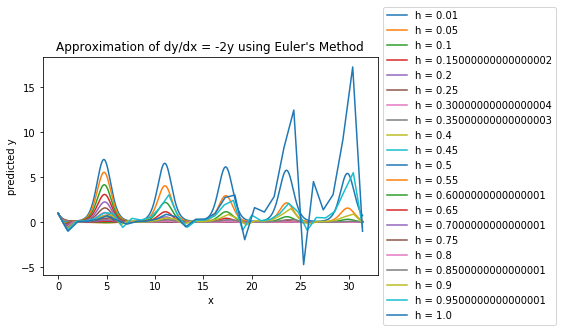

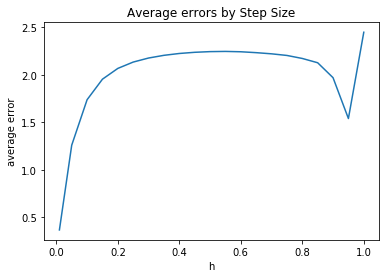

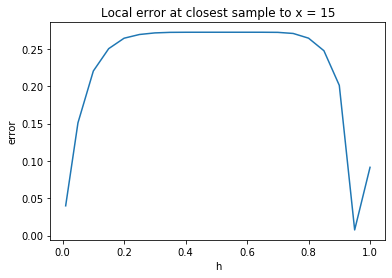

In [52]:
h_list = np.linspace(0.00, 1, 21)
h_list[0] = 0.01
y_15_list = np.zeros(len(h_list))
avg_errors = np.zeros(len(h_list))

#Define base parameters
x_start, x_end = 0, 10*np.pi

for j in range(0, len(h_list)):
    h = h_list[j]
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values= np.zeros(num_steps + 1)
    y_values[0] = 1  # y(0) = 1
    
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    errors = np.zeros(len(x_values))
    
    for i in range(0, len(errors)):
        errors[i] = np.abs(y_values[i] - exact(x_values[i], y_values[0]))
    plt.plot(x_values, y_values, label="h = " + str(h))
    
    idx_15 = np.argmin(np.abs(x_values - 15))
    y_15_list[j] = y_values[idx_15]
    
    total_error = np.sum(errors)
    avg_errors[j] = total_error/len(errors)
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("x")
plt.ylabel("predicted y")
plt.show()

plt.title("Average errors by Step Size")
plt.plot(h_list, avg_errors)
plt.xlabel("h")
plt.ylabel("average error")
plt.show()

y_15_errors = np.abs(y_15_list - exact(15, 1))
plt.plot(h_list, y_15_errors)
plt.title("Local error at closest sample to x = 15")
plt.xlabel("h")
plt.ylabel("error")
plt.show()

Higher step sizes become less accurate over time, especially on average. At individual points, they can "accidentally" be accurate due to oscillatory patterns. Still, the average error is clearly significantly lower with a small step size.

Lambda is a function of x due to the trig term! Lambda(x) = -2cos(x). 

Stability condition:

∣1 + h𝜆(x)| < 1

Best case scenario: cos(x) = 1, then |1-2h| < 1 means that 0 < h < 1

Worst case scenario is that cos(x) = -1, then |1 + 2h| < 1, which is not true for any positive h. Thus, there is no step size that guarantees the stability of the euler method across the whole region because stability condition needs to hold for all lambda.